# Ejercicio de Detección de Anomalías en Series Temporales

## 1. Objetivo del ejercicio
Trabajar con un dataset sintético de series temporales que contiene tres tipos de anomalías simultáneas (Puntuales, Contextuales y Colectivas). El objetivo es comprender la estructura temporal, aplicar técnicas combinadas y evaluar los resultados.

## 2. Dataset sintético: Serie temporal compleja
A continuación, generamos un dataset temporal realista con tendencia, estacionalidad y ruido, inyectando los tres tipos de anomalías.

C:\Users\tteru\AppData\Local\Temp\ipykernel_12928\2152813175.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range('2022-01-01', periods=timesteps, freq='H')


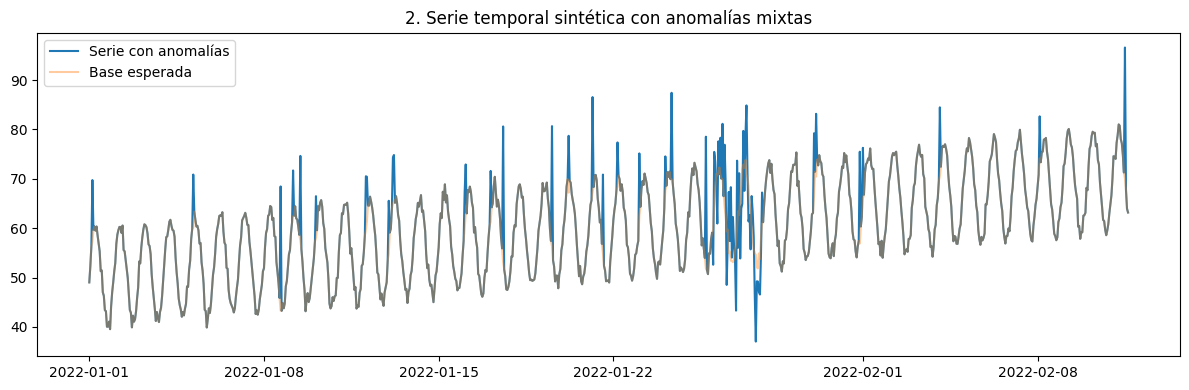

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración inicial
rng = np.random.default_rng(123)
timesteps = 1000
idx = pd.date_range('2022-01-01', periods=timesteps, freq='H')

# Componentes base
tendencia = np.linspace(0, 20, timesteps) # crecimiento lento
estacionalidad = 10 * np.sin(2 * np.pi * np.arange(timesteps) / 24) # ciclo diario
ruido = rng.normal(0, 1, timesteps)
base = 50 + tendencia + estacionalidad + ruido

# Copia modificable
serie = base.copy()

# --- Anomalías puntuales ---
spikes_idx = rng.choice(timesteps, size=12, replace=False)
serie[spikes_idx] += rng.normal(20, 4, size=12)

# --- Anomalías contextuales (noches) ---
night_hours = np.where((idx.hour >= 0) & (idx.hour <= 5))[0]
context_idx = rng.choice(night_hours, size=20, replace=False)
serie[context_idx] += rng.normal(10, 2, size=20)

# --- Anomalías colectivas ---
start_seg = 600
length_seg = 48
serie[start_seg:start_seg+length_seg] += rng.normal(0, 8, length_seg)

# DataFrame final
df_ts = pd.DataFrame({'timestamp': idx, 'valor': serie, 'base': base}).set_index('timestamp')

# Visualización original
plt.figure(figsize=(12,4))
plt.plot(df_ts.index, df_ts['valor'], label='Serie con anomalías')
plt.plot(df_ts.index, df_ts['base'], alpha=0.4, label='Base esperada')
plt.title('2. Serie temporal sintética con anomalías mixtas')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Tareas del ejercicio
### 3.1 Visualización inicial

Para entender la estructura de los datos antes de aplicar modelos de Machine Learning, realizamos dos visualizaciones clave:
1. **Media móvil y Desviación estándar móvil (Rolling mean & std)**.
2. **Histograma de diferencias**.

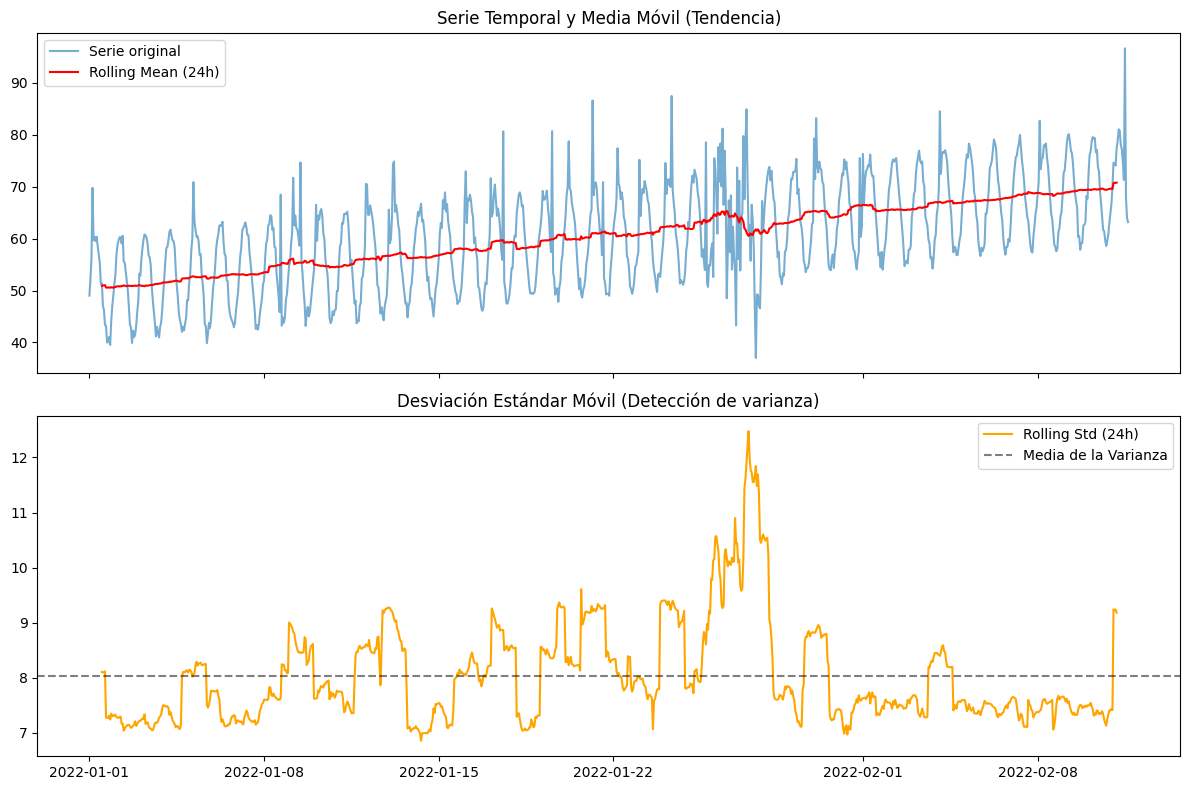

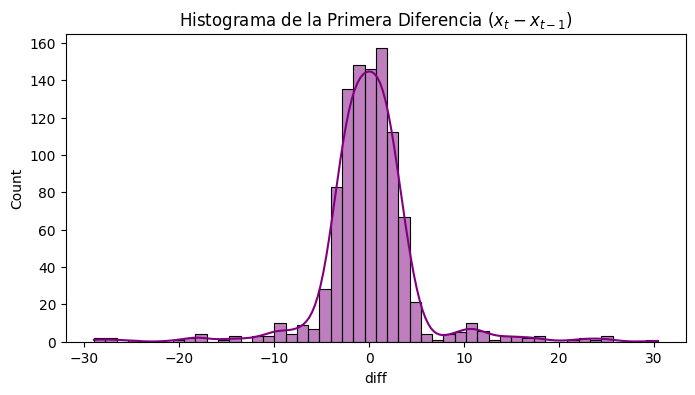

In [2]:
# 1. Rolling Mean y Rolling Std (Ventana de 24 horas)
window_size = 24
df_ts['rolling_mean'] = df_ts['valor'].rolling(window=window_size, center=True).mean()
df_ts['rolling_std'] = df_ts['valor'].rolling(window=window_size, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df_ts.index, df_ts['valor'], label='Serie original', alpha=0.6)
axes[0].plot(df_ts.index, df_ts['rolling_mean'], color='red', label='Rolling Mean (24h)')
axes[0].set_title('Serie Temporal y Media Móvil (Tendencia)')
axes[0].legend()

axes[1].plot(df_ts.index, df_ts['rolling_std'], color='orange', label='Rolling Std (24h)')
axes[1].axhline(df_ts['rolling_std'].mean(), color='black', linestyle='--', alpha=0.5, label='Media de la Varianza')
axes[1].set_title('Desviación Estándar Móvil (Detección de varianza)')
axes[1].legend()
plt.tight_layout()
plt.show()

# 2. Histograma de Diferencias (Diff)
df_ts['diff'] = df_ts['valor'].diff()
plt.figure(figsize=(8, 4))
sns.histplot(df_ts['diff'].dropna(), bins=50, kde=True, color='purple')
plt.title('Histograma de la Primera Diferencia ($x_t - x_{t-1}$)')
plt.show()

**Interpretación de las visualizaciones (3.1):**
* **Rolling Mean y Std:** La gráfica superior (Media Móvil) nos ayuda a ver la tendencia creciente eliminando el ruido diario. La gráfica inferior (Rolling Std) revela un pico masivo sostenido justo después del día 25 (índice 600 aprox.). Esto expone claramente la **anomalía colectiva** (el segmento de alta varianza).
* **Histograma de Diferencias:** Muestra una distribución normal central (el ruido estándar), pero observamos colas muy extendidas con valores aislados (por encima de 10 y por debajo de -10). Estos valores extremos en las diferencias de un paso a otro representan las **anomalías puntuales** (picos bruscos).

### 3.2 Técnicas recomendadas (Combinación de métodos)

Para lograr una detección robusta de los tres tipos de anomalías, vamos a combinar dos técnicas:
1. **Z-Score Local (Estadística de ventanas):** Excelente para detectar *anomalías puntuales* (spikes rápidos).
2. **Isolation Forest (Machine Learning con contexto temporal):** Excelente para detectar *anomalías contextuales* (usando la hora del día) y *colectivas* (usando la desviación estándar móvil).

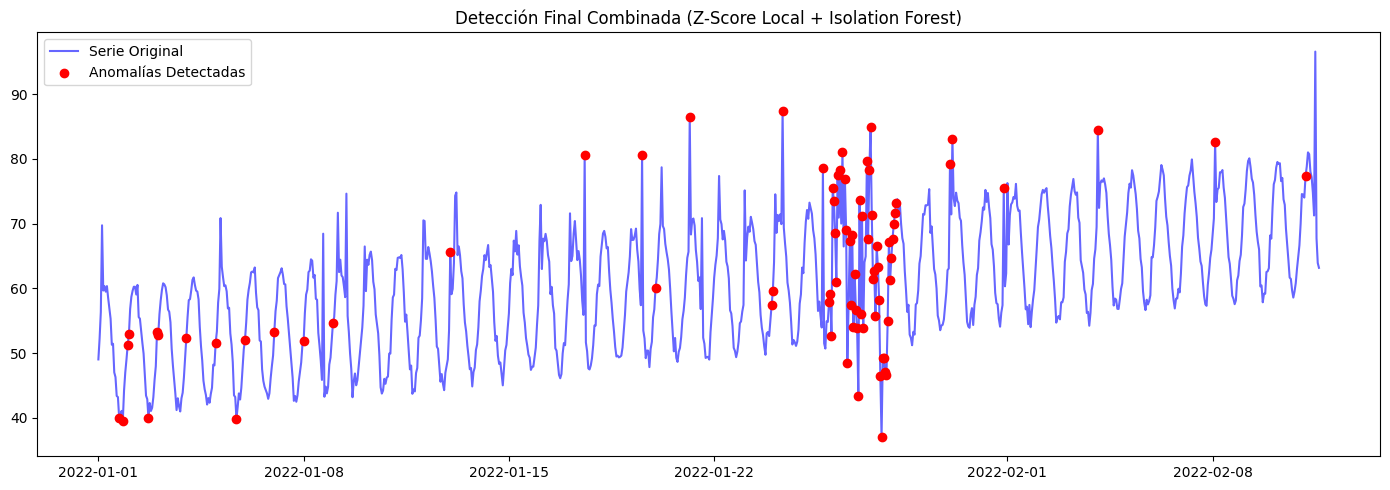

In [3]:
from sklearn.ensemble import IsolationForest

# --- MÉTODO 1: Z-Score Local (Para anomalías puntuales) ---
# Usamos una ventana corta (6 horas) para detectar picos rápidos
df_ts['roll_mean_short'] = df_ts['valor'].rolling(window=6, center=True).mean()
df_ts['roll_std_short'] = df_ts['valor'].rolling(window=6, center=True).std()

# Calculamos Z-score: (valor - media_local) / std_local
df_ts['z_score_local'] = (df_ts['valor'] - df_ts['roll_mean_short']) / (df_ts['roll_std_short'] + 1e-6)

# Umbral estricto: Z-score absoluto > 3 es anomalía
df_ts['anomaly_zscore'] = (df_ts['z_score_local'].abs() > 3.0).astype(int)


# --- MÉTODO 2: Isolation Forest (Para contextuales y colectivas) ---
# Creamos variables (features) que le den contexto temporal al algoritmo
df_ts['hour'] = df_ts.index.hour
features = ['valor', 'hour', 'rolling_std'] # Incluimos rolling_std calculada en la sección 3.1
df_ml = df_ts[features].dropna()

# Entrenamos el modelo estimando un 8% de contaminación (basado en la generación de datos)
iso_forest = IsolationForest(contamination=0.08, random_state=42)
df_ts.loc[df_ml.index, 'anomaly_if'] = iso_forest.fit_predict(df_ml)

# Isolation forest devuelve -1 para anomalía y 1 para normal. Lo pasamos a 1 y 0.
df_ts['anomaly_if'] = df_ts['anomaly_if'].apply(lambda x: 1 if x == -1 else 0)


# --- COMBINACIÓN DE RESULTADOS ---
# Marcamos como anomalía final si cualquiera de los dos métodos la detecta (Operador OR '|')
df_ts['anomaly_final'] = ((df_ts['anomaly_zscore'] == 1) | (df_ts['anomaly_if'] == 1)).astype(int)

# --- VISUALIZACIÓN FINAL DE ANOMALÍAS DETECTADAS ---
plt.figure(figsize=(14, 5))
plt.plot(df_ts.index, df_ts['valor'], label='Serie Original', color='blue', alpha=0.6)

# Extraer los puntos donde anomaly_final es 1
anomalies = df_ts[df_ts['anomaly_final'] == 1]
plt.scatter(anomalies.index, anomalies['valor'], color='red', label='Anomalías Detectadas', zorder=5)

plt.title('Detección Final Combinada (Z-Score Local + Isolation Forest)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Exposición (Respuestas teóricas)

Para la presentación con tu compañero, aquí están las respuestas argumentadas a las preguntas planteadas:

**1. ¿Qué anomalías detecta mejor cada técnica?**
* **Z-score local:** Es ideal para las *anomalías puntuales* (picos/spikes). Al mirar una ventana muy corta (ej. 6 horas), detecta saltos bruscos que no tienen sentido con el valor inmediatamente anterior o posterior.
* **Isolation Forest:** Gracias a que le pasamos las variables "hora" y "desviación estándar móvil", es excelente detectando *anomalías contextuales* (sabe que un valor alto en la madrugada no es normal, aunque sí lo sea a mediodía) y *colectivas* (detecta la región prolongada de alta varianza).

**2. ¿Qué anomalías pasan desapercibidas con técnicas simples?**
Si usáramos un simple umbral estático (ej. "marcar todo lo que pase de 60"), fallaríamos por la *tendencia* (los últimos días darían falsos positivos por ser más altos). Además, las *anomalías contextuales* pasarían desapercibidas, ya que un valor que parece normal globalmente puede ser una anomalía dependiendo del contexto temporal (la hora del día).

**3. ¿Qué combinación de métodos ofrece los mejores resultados? ¿Por qué?**
La combinación de **Estadística Local (Z-score en ventanas)** + **Machine Learning Multivariante (Isolation Forest)**. Ningún método por sí solo es perfecto: Z-score sufre en zonas de alta varianza constante, y el Isolation Forest a veces ignora picos aislados si no son lo suficientemente extremos globalmente. Al combinarlos (usando una regla *OR* lógica), cubrimos los puntos débiles del otro.

**4. ¿Cómo afecta el tamaño de la ventana?**
Es el factor más crítico:
* **Ventana muy corta:** Hace al modelo demasiado sensible al ruido "normal", generando muchos falsos positivos (marcará como anomalía variaciones normales).
* **Ventana muy larga:** Suaviza demasiado los datos (Over-smoothing). Las anomalías colectivas cortas se diluirán en la media global y no serán detectadas.

**5. ¿Cómo influyen parámetros como contamination, nu, n_neighbors, eps?**
Controlan la "sensibilidad" del modelo:
* **Contamination (Isolation Forest):** Define qué porcentaje de los datos le decimos al modelo que son anómalos. Si es muy bajo, tendremos falsos negativos (no detectaremos anomalías reales); si es muy alto, tendremos falsos positivos (marcaremos ruido normal como anomalía).
* **n_neighbors (LOF) / eps (DBSCAN):** Definen qué tan "lejos" miramos para definir si un punto está solo. Un vecindario pequeño busca anomalías muy locales; uno grande busca anomalías respecto a tendencias más generales de todo el dataset.